<a href="https://colab.research.google.com/github/avishek-astra/Deep_Learning_Experiments/blob/main/CNN_GaussAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

#summary info on labels
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

Create Gaussian blurs with different width

In [9]:
nGauss=1000
imgSize=91

x=np.linspace(-4,4,imgSize)
X,Y=np.meshgrid(x,x)

#the two widths(a.u.)
widths=[1.8,2.4]

#initialize tensors containing images and labels
images=torch.zeros(nGauss,1,imgSize,imgSize)

for i in range(nGauss):
  #create the guassian with random centers
  ro=2*np.random.randn(2)
  G=np.exp(-((X-ro[0])**2+(Y-ro[1])**2)/(2*widths[i%2]**2))

  #and add noise
  G=G+np.random.randn(imgSize,imgSize)/5
  # add a random bar randomly
  i1=np.random.choice(np.arange(2,28))
  i2=np.random.choice(np.arange(2,28))
  if np.random.randn()>0:
    G[i1:i1+i2,:]=1
  else:
    G[:,i1:i1+i2]=1

  ##add to the tensor
  images[i,:,:,:]=torch.Tensor(G).view(1,imgSize,imgSize)



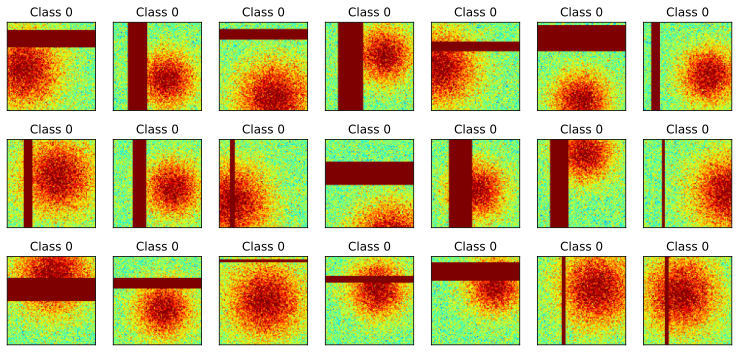

In [10]:
#visualize some images
fig,axs=plt.subplots(3,7,figsize=(13,6))
for i,ax in enumerate(axs.flatten()):
  whichpic=np.random.randint(nGauss)
  G=np.squeeze(images[whichpic,:,:])
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  ax.set_title('Class %s'%int(labels[whichpic].item()))
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

Create train/test groups using DataLoader

Create the DL model

In [11]:
from typing import NewType
#create a class for the model
def makeTheNet():
  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()
      self.enc=nn.Sequential(
          nn.Conv2d(1,6,3,padding=1),  # output size: (91+2*1-3)/1 + 1 = 91
          nn.ReLU(),                   # note that relu is treated like a "layer"
          nn.MaxPool2d(2,2),           # output size: 91/2 = 45
          nn.Conv2d(6,4,3,padding=1),  # output size: (45+2*1-3)/1 + 1 = 45
          nn.ReLU(),
          nn.MaxPool2d(2,2),           # output size: 45/2 = 22
        )
      #decoding layer
      self.dec=nn.Sequential(
          nn.ConvTranspose2d(4,6,3,2),
          nn.ReLU(),
          nn.ConvTranspose2d(6,1,3,2),
      )
    def forward(self,x):
      return self.dec(self.enc(x))
  #create the model instance
  net=gausnet()
  #loss function
  lossfun=nn.MSELoss()
  #optimizer
  optimizer=torch.optim.Adam(net.parameters(),lr=0.001)
  return net,lossfun,optimizer



torch.Size([10, 1, 91, 91])


Text(0.5, 1.0, 'Model output')

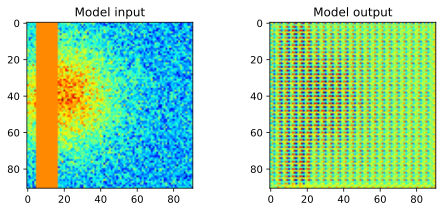

In [12]:
#test the model with one batch
net,lossfun,optimizer=makeTheNet()
yHat=net(images[:10,:,:,:])

#check sizes of the output
print('')
print(yHat.shape)

# let's see how they look
fig,ax = plt.subplots(1,2,figsize=(8,3))
ax[0].imshow(torch.squeeze(images[0,0,:,:]).detach(),cmap='jet')
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(yHat[0,0,:,:]).detach(),cmap='jet')
ax[1].set_title('Model output')

In [13]:

# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.24
Params size (MB): 0.00
Estimated Total Size (MB): 1.27
---------------------------------------------------

Create a function that trains the model

In [16]:
# a function that trains the model
def function2trainTheModel():
  #number of epochs
  numepochs=500
  #create a new model
  net,lossfun,optimizer=makeTheNet()

  #initialize losses
  losses=torch.zeros(numepochs)

  #loop over epochs
  for epochi in range(numepochs):
    #pick a set of images at random
    pics2use=np.random.choice(nGauss,size=32,replace=False)
    X=images[pics2use,:,:,:]
    #forward pass and loss
    yHat=net(X)
    loss=lossfun(yHat,X)
    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  #function output

  return losses,net

Run the model and show the results!

In [17]:
losses,net = function2trainTheModel()


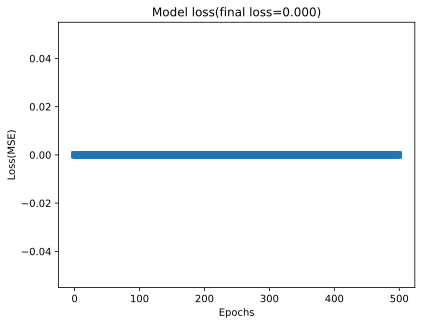

In [19]:
plt.plot(losses,'s-',label='Train')
plt.xlabel('Epochs')
plt.ylabel('Loss(MSE)')
plt.title('Model loss(final loss=%.3f)'%losses[-1])
plt.show()

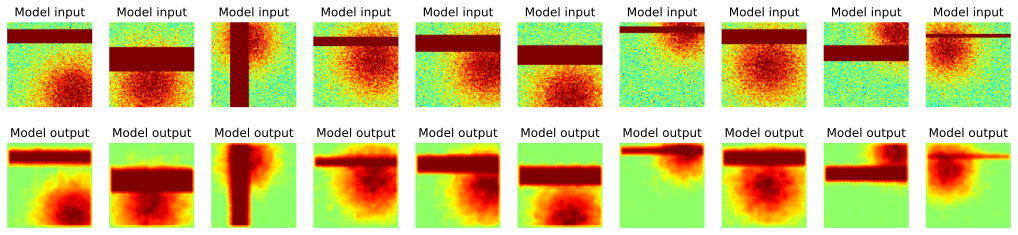

In [22]:
#visualize some images
pics2use=np.random.choice(nGauss,size=10,replace=False)
X=images[pics2use,:,:,:]
yHat=net(X)
fig,axs=plt.subplots(2,10,figsize=(18,4))
for i in range(10):
  G=torch.squeeze(X[i,:,:,:]).detach()
  O=torch.squeeze(yHat[i,:,:,:]).detach()
  axs[0,i].imshow(G,vmin=-1,vmax=1,cmap='jet')
  axs[0,i].axis('off')
  axs[0,i].set_title('Model input')

  axs[1,i].imshow(O,vmin=-1,vmax=1,cmap='jet')
  axs[1,i].axis('off')
  axs[1,i].set_title('Model output')
plt.show()

In [ ]:
#look at the filters
print(net)

layer1W=net.enc[0].weight
layer3W=net.enc[3].weight


print(' ')
print(layer1W.shape)
print(layer3W.shape)

gausnet(
  (enc): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1936, out_features=50, bias=True)
    (8): Linear(in_features=50, out_features=1, bias=True)
  )
)
 
torch.Size([6, 1, 3, 3])
torch.Size([4, 6, 3, 3])


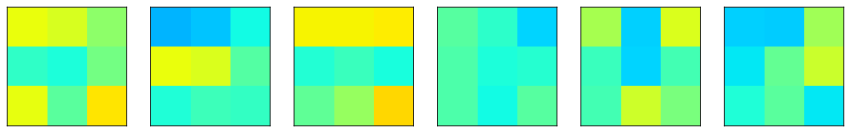

In [ ]:
fig,axs=plt.subplots(1,6,figsize=(15,3))
for i,ax in enumerate(axs.flatten()):
  G=torch.squeeze(layer1W[i,:,:,:]).detach()
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

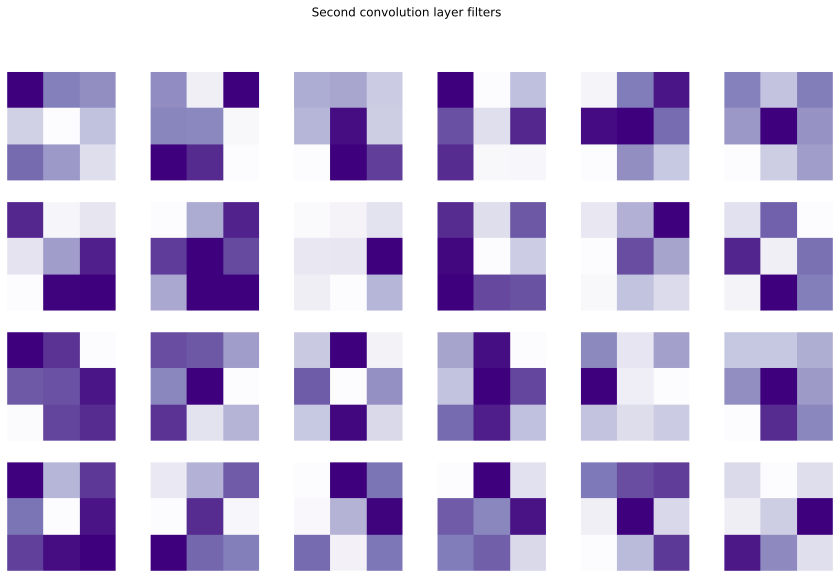

In [ ]:
fig,axs = plt.subplots(4,6,figsize=(15,9))

for i in range(6*4):
  idx = np.unravel_index(i,(4,6))
  axs[idx].imshow( torch.squeeze(layer3W[idx[0],idx[1],:,:]).detach() ,cmap='Purples')
  axs[idx].axis('off')

plt.suptitle('Second convolution layer filters')
plt.show()